# PINN Thermal Problem

Check out the first example of the reference paper for more details: Physics-informed neural network solution of thermo-hydro-mechanical (THM) processes in porous media

Find the paper at: https://arxiv.org/abs/2203.01514


## GradNorm Adaptive Weighting

GradNorm is an adaptive loss-weighting method that balances multiple objective terms by controlling their gradient magnitudes during training. For a model trained with $N$ loss terms, the total weighted loss is written as

$$
L_{\text{total}}(t) = \sum_{i=1}^{N} w_i(t) L_i(t)
$$

where:

- $N$ is the total number of loss terms or tasks,
- $i$ is the index of a specific loss term,
- $t$ is the training iteration or epoch,
- $L_i(t)$ is the value of the $i$-th loss term at iteration $t$,
- $w_i(t)$ is the adaptive weight assigned to the $i$-th loss term.

GradNorm measures the gradient norm of each weighted loss with respect to a selected shared set of model parameters $\theta_s$:

$$
G_i(t) =
\left\|
\nabla_{\theta_s}
\left(
w_i(t)L_i(t)
\right)
\right\|_2
$$

where:

- $G_i(t)$ is the gradient norm of the $i$-th weighted loss,
- $\theta_s$ is a selected subset of shared model parameters, often the last shared layer,
- $\nabla_{\theta_s}$ means the gradient with respect to $\theta_s$,
- $\|\cdot\|_2$ denotes the Euclidean norm.

The average gradient norm over all loss terms is

$$
\bar{G}(t) = \frac{1}{N} \sum_{i=1}^{N} G_i(t)
$$

where $\bar{G}(t)$ represents the mean gradient magnitude across all loss terms.

To compare the relative training speed of each loss term, each loss is normalized by its initial value:

$$
\tilde{L}_i(t) = \frac{L_i(t)}{L_i(0)}
$$

where:

- $\tilde{L}_i(t)$ is the normalized loss ratio,
- $L_i(0)$ is the initial value of the $i$-th loss term.

The relative inverse training rate is then defined as

$$
r_i(t) =
\frac{
\tilde{L}_i(t)
}{
\frac{1}{N}\sum_{j=1}^{N}\tilde{L}_j(t)
}
$$

where:

- $r_i(t)$ measures whether the $i$-th loss is training faster or slower than the average,
- $j$ is an index used to sum over all loss terms.

The target gradient norm for each loss term is

$$
G_i^*(t) =
\bar{G}(t)
\left[
r_i(t)
\right]^\alpha
$$

where:

- $G_i^*(t)$ is the desired target gradient norm for the $i$-th loss term,
- $\alpha$ is a hyperparameter controlling the strength of the GradNorm correction.

Finally, the adaptive weights $w_i(t)$ are updated by minimizing the GradNorm loss:

$$
L_{\text{grad}} =
\sum_{i=1}^{N}
\left|
G_i(t) - G_i^*(t)
\right|
$$

where $L_{\text{grad}}$ penalizes differences between the actual gradient norms and the target gradient norms.

In summary, GradNorm does not force all loss values to become equal. Instead, it adjusts the weights $w_i(t)$ so that the different loss terms contribute balanced gradient magnitudes to the training process.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import os, time
import matplotlib.pyplot as plt

In [ ]:
# Unit conversions
s, minute, hr, day = 1., 60., 60.**2, 24*60.**2
g, kg = 1.e-3, 1.
mm, cm, m, km = 1e-3, 1e-2, 1.0, 1e3
Pa, kPa, MPa, GPa = 1.0, 1.e3, 1.e6, 1.e9
micro, milli, centi, kilo, mega = 1e-6, 1e-3, 1e-2, 1e3, 1e6
poise = 0.1*Pa*s
Darcy = 9.869233e-13*m**2

# ----------------------- Constant Parameters----------------------
DTYPE = 'float32'
phi = 0.5
rho_s = 2000.0 * kg/m**3
rho_f = 1000. * kg/m**3
mu = 1e-3
k = 1.98e-5
beta_s = 0.0
beta_f = 0.0
b = 1.0
Ly = 0.1*m
C_s = 0.201
C_f = 0.201
rho_C_avg = (1-phi)*rho_s*C_s + phi*rho_f*C_f
Lambda_avg = 2.6

# ----------------------- Dimensionless parameters -----------------------
p_star = 1 *Pa
x_star = Ly
t_star = 0.5*s
T_star = 100
td_0 = 0.0
td_f = 0.5*s/t_star
yd_min = 0.0
yd_max = (Ly/x_star)
rho_C_bar = rho_C_avg

beta_s_f = (b-phi)*beta_s + phi*beta_f
C_star = rho_C_avg/rho_C_bar
J_star = k*p_star*t_star/(mu*(x_star**2))
F_star = (Lambda_avg*t_star)/(rho_C_bar*(x_star**2))

In [ ]:
# ----------------------- Neural Network Setup -----------------------
#sn.reset_session()
torch.manual_seed(124) #sn.set_random_seed(124)

yd_1D = torch.linspace(yd_min, yd_max, 30)
td_1D = torch.linspace(td_0, td_f, 30)
yd_mesh, td_mesh = torch.meshgrid(yd_1D, td_1D, indexing='ij')
yd_phys = yd_mesh.reshape(-1,1).clone().detach().requires_grad_(True)
td_phys = td_mesh.reshape(-1,1).clone().detach().requires_grad_(True)

# meshgrid creation:
yd_ic = torch.linspace(0,1,1000,requires_grad=True).view(-1,1)
td_ic = torch.zeros_like(yd_ic)

td_bc1 = torch.linspace(0,1,1000,requires_grad=True)[1:].view(-1,1)
yd_bc1 = torch.zeros_like(td_bc1)

td_bc2 = torch.linspace(0,1,1000,requires_grad=True)[1:].view(-1,1)
yd_bc2 = torch.ones_like(td_bc2)

# IC and BC points:

class Functional(nn.Module):
  def __init__(self,):
    super(Functional, self).__init__()
    self.Network = nn.Sequential(
        nn.Linear(2, 20),
        nn.Tanh(),
        # nn.Linear(20,20),
        # nn.Tanh(),
        nn.Linear(20,20),
        nn.Tanh(),
        nn.Linear(20,20),
        nn.Tanh(),
        nn.Linear(20,1)
    )



  def forward(self, x, t):
    inputs = torch.cat([x,t], dim=1)
    return self.Network(inputs)


PINN_Func = Functional()
LW_eq = nn.Parameter(torch.tensor([1.0])) # loss weight equation
LW_ic = nn.Parameter(torch.tensor([1.0]))
LW_bc1 = nn.Parameter(torch.tensor([1.0]))
LW_bc2 = nn.Parameter(torch.tensor([1.0]))
# y = yd*x_star
# t = td*t_star
# T = Td*T_star


In [ ]:
last_layer = PINN_Func.Network[-1]
LL_Param = list(last_layer.parameters())
# weights = last_layer.weight
# bias = last_layer.bias
# weights, bias
LL_Param

[Parameter containing:
 tensor([[-0.1797,  0.0194,  0.0067, -0.1759,  0.2065,  0.0068,  0.0974,  0.2209,
           0.0979, -0.2144, -0.1693,  0.1193, -0.2015,  0.1039,  0.1643, -0.0011,
          -0.1351, -0.0124,  0.1191,  0.0466]], requires_grad=True),
 Parameter containing:
 tensor([0.0102], requires_grad=True)]

In [ ]:
PINN_Func.named_parameters()

<generator object Module.named_parameters at 0x7fe51a3b9740>

In [ ]:
num_epochs = 10000
initial_lr = 2.5e-3
final_lr = 1e-4
gamma = (final_lr/initial_lr)**(1/num_epochs)

M_optim = torch.optim.Adam(PINN_Func.parameters(), lr=initial_lr)
GN_optim = torch.optim.Adam([LW_eq, LW_ic, LW_bc1, LW_bc2], lr=0.5e-4)

scheduler = torch.optim.lr_scheduler.ExponentialLR(M_optim, gamma=gamma)

pd_yd = 1

In [ ]:

loss_total_history, loss_ic_hist, loss_bc1_hist, loss_bc2_hist, loss_eq_hist = [],[],[],[],[]
for epoch in range(num_epochs):

  M_optim.zero_grad()
  GN_optim.zero_grad()

  Td_dom = PINN_Func(yd_phys, td_phys)
  dT_dt = torch.autograd.grad(outputs=Td_dom, inputs=td_phys, grad_outputs=torch.ones_like(Td_dom), create_graph=True)[0]#, retain_graph=True)
  dT_dy = torch.autograd.grad(outputs=Td_dom, inputs=yd_phys, grad_outputs=torch.ones_like(Td_dom), create_graph=True)[0]#, retain_graph=True)
  d2T_dy2 = torch.autograd.grad(outputs=dT_dy, inputs=yd_phys, grad_outputs=torch.ones_like(dT_dy), create_graph=True)[0] #, retain_graph=True)

  equation = C_star* dT_dt - J_star*(rho_f*C_f/rho_C_bar)*pd_yd*dT_dy - F_star*d2T_dy2
  L_eq = torch.mean(equation**2)

  Td_bc1 = PINN_Func(yd_bc1, td_bc1)
  L_bc1 = torch.mean(Td_bc1**2)

  Td_bc2 = PINN_Func(yd_bc2, td_bc2)
  L_bc2 =  torch.mean((Td_bc2-100/T_star)**2)

  Td_ic = PINN_Func(yd_ic, td_ic)
  L_ic = torch.mean((Td_ic)**2)
  # --- grad norm adaptive weights --- #
  if epoch ==0:
    L0_eq = L_eq.detach()
    L0_ic = L_ic.detach()
    L0_bc1 = L_bc1.detach()
    L0_bc2 = L_bc2.detach()

  LB_eq = L_eq/L0_eq
  LB_ic = L_ic/L0_ic
  LB_bc1 = L_bc1/L0_bc1
  LB_bc2 = L_bc2/L0_bc2

  LB_avg = 0.25*(LB_eq+LB_ic+LB_bc1+LB_bc2)

  R_eq = (LB_eq/LB_avg).detach()
  R_ic = (LB_ic/LB_avg).detach()
  R_bc1 = (LB_bc1/LB_avg).detach()
  R_bc2 = (LB_bc2/LB_avg).detach()

  Grad_eq = torch.autograd.grad(LW_eq*L_eq, LL_Param, grad_outputs=torch.ones_like(LW_eq*L_eq),
                            retain_graph=True, create_graph=True, allow_unused=True)[0]
  Grad_ic = torch.autograd.grad(LW_ic*L_ic, LL_Param, grad_outputs=torch.ones_like(LW_ic*L_ic),
                            retain_graph=True, create_graph=True, allow_unused=True)[0]
  Grad_bc1 = torch.autograd.grad(LW_bc1*L_bc1, LL_Param, grad_outputs=torch.ones_like(LW_bc1*L_bc1),
                              retain_graph=True, create_graph=True, allow_unused=True)[0]
  Grad_bc2 = torch.autograd.grad(LW_bc2*L_bc2, LL_Param, grad_outputs=torch.ones_like(LW_bc2*L_bc2),
                              retain_graph=True, create_graph=True, allow_unused=True)[0]

  G_eq = torch.norm(Grad_eq, p=2)
  G_ic = torch.norm(Grad_ic, p=2)
  G_bc1 = torch.norm(Grad_bc1, p=2)
  G_bc2 = torch.norm(Grad_bc2, p=2)

  GB_avg = 0.25*(G_eq + G_ic + G_bc1 + G_bc2).detach()
  alpha = 0.5 #0.9

  GS_eq = (GB_avg*(R_eq**alpha))
  GS_ic = (GB_avg*(R_ic**alpha))
  GS_bc1 = (GB_avg*(R_bc1**alpha))
  GS_bc2 = (GB_avg*(R_bc2**alpha))


  GN_loss = torch.abs(G_eq-GS_eq)+torch.abs(G_ic-GS_ic)+torch.abs(G_bc1-GS_bc1)+torch.abs(G_bc2-GS_bc2)

  L_value = LW_eq.detach()*L_eq + LW_bc1.detach()*L_bc1 + LW_bc2.detach()*L_bc2 + LW_ic.detach()*L_ic

  loss_total_history.append(L_value.item())
  loss_eq_hist.append(L_eq.item())
  loss_ic_hist.append(L_ic.item())
  loss_bc1_hist.append(L_bc1.item())
  loss_bc2_hist.append(L_bc2.item())

  # # --- loss calculation --- #
  GN_loss.backward(retain_graph=True)
  # print("After GN_loss.backward():")
  # print("LW_eq grad: {}".format(LW_eq.grad))
  # print("LW_ic grad: {}".format(LW_ic.grad))
  # print("LW_bc1 grad: {}".format(LW_bc1.grad))
  # print("LW_bc2 grad: {}".format(LW_bc2.grad))

  # model_grad_norm = 0.0
  # for name, p in PINN_Func.named_parameters():
  #   if p.grad is not None:
  #     gnorm = p.grad.norm().item()
  #     model_grad_norm += gnorm
  #     print(name, gnorm)

  # print("Total model grad norm from GN_loss:", model_grad_norm)
  #

  M_optim.zero_grad()

  L_value.backward()

  # print("After L_value.backward()")

  # print("LW_eq grad:{}".format(LW_eq.grad))
  # print("LW_ic grad:{}".format(LW_ic.grad))
  # print("LW_bc1 grad:{}".format(LW_bc1.grad))
  # print("LW_bc2 grad:{}".format(LW_bc2.grad))

  # for name, p in PINN_Func.named_parameters():
  #   if p.grad is not None:
  #     print(name, p.grad.norm().item())


  GN_optim.step()

  with torch.no_grad():
    LW_eq.clamp_(min=0.1)
    LW_ic.clamp_(min=0.1)
    LW_bc1.clamp_(min=0.1)
    LW_bc2.clamp_(min=0.1)

    W_sum = LW_eq + LW_ic + LW_bc1 + LW_bc2

    LW_eq *= 4.0 / W_sum
    LW_ic *= 4.0 / W_sum
    LW_bc1 *= 4.0 / W_sum
    LW_bc2 *= 4.0 / W_sum


  M_optim.step()
  scheduler.step()



  # if epoch % 500 == 499:
  #   print("Epoch {}/{}, Loss:{}".format(epoch+1, num_epochs, L_value.item()))
  if epoch % 500 == 499:
    print("Epoch:", epoch+1)
    print("Losses: {:.5f}, {:.5f}, {:.5f}, {:.5f}".format(L_eq.item(), L_ic.item(), L_bc1.item(), L_bc2.item()))
    print("Weights: {:.5f}, {:.5f}, {:.5f}, {:.5f}".format(LW_eq.item(), LW_ic.item(), LW_bc1.item(), LW_bc2.item()))
    print("Weighted Losses: {:.5f}, {:.5f}, {:.5f}, {:.5f}".format(
        (LW_eq*L_eq).item(), (LW_ic*L_ic).item(),
        (LW_bc1*L_bc1).item(), (LW_bc2*L_bc2).item()))
    print("G: {:.5f}, {:.5f}, {:.5f}, {:.5f}".format(G_eq.item(), G_ic.item(), G_bc1.item(), G_bc2.item()))
    print("R: {:.5f}, {:.5f}, {:.5f}, {:.5f}".format(R_eq.item(), R_ic.item(), R_bc1.item(), R_bc2.item()))
    print("Total:", L_value.item())




Epoch: 500
Losses: 0.00528, 0.01774, 0.00125, 0.02109
Weights: 1.00562, 1.01810, 0.98937, 0.98691
Weighted Losses: 0.00531, 0.01806, 0.00124, 0.02081
G: 0.01619, 0.13950, 0.04100, 0.13135
R: 0.21890, 3.73865, 0.03985, 0.00261
Total: 0.04542393609881401
Epoch: 1000
Losses: 0.00153, 0.00962, 0.00078, 0.01113
Weights: 0.99773, 1.03585, 0.98395, 0.98247
Weighted Losses: 0.00153, 0.00997, 0.00077, 0.01093
G: 0.03237, 0.12537, 0.04755, 0.08450
R: 0.12000, 3.83069, 0.04671, 0.00260
Total: 0.02319919317960739
Epoch: 1500
Losses: 0.00120, 0.00588, 0.00069, 0.00846
Weights: 0.98798, 1.05898, 0.97318, 0.97986
Weighted Losses: 0.00118, 0.00623, 0.00067, 0.00829
G: 0.01669, 0.09892, 0.04950, 0.06339
R: 0.15129, 3.77893, 0.06659, 0.00319
Total: 0.016377713531255722
Epoch: 2000
Losses: 0.00102, 0.00423, 0.00042, 0.00700
Weights: 0.98593, 1.07883, 0.95999, 0.97524
Weighted Losses: 0.00101, 0.00456, 0.00040, 0.00683
G: 0.01068, 0.07959, 0.04095, 0.05036
R: 0.17874, 3.76157, 0.05603, 0.00366
Total: 0.01

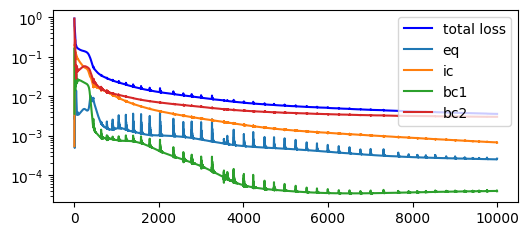

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,2.5))
ax.semilogy(loss_total_history, color='blue', label='total loss')
ax.semilogy(loss_eq_hist, label='eq')
ax.semilogy(loss_ic_hist, label='ic')
ax.semilogy(loss_bc1_hist, label='bc1')
ax.semilogy(loss_bc2_hist, label='bc2')
ax.legend()
plt.show()

In [ ]:
# --- plotting the outputs ----
yd_eval1 = torch.linspace(0,1,100).view(-1,1)
td_eval1 = torch.ones_like(yd_eval1)*0.01/t_star

yd_eval2 = torch.linspace(0,1,100).view(-1,1)
td_eval2 = torch.ones_like(yd_eval2)*0.05/t_star

yd_eval3 = torch.linspace(0,1,100).view(-1,1)
td_eval3 = torch.ones_like(yd_eval3)*0.5/t_star

with torch.no_grad():
  PINN_Func.eval()
  Td_eval1 = PINN_Func(yd_eval1, td_eval1)
  Td_eval2 = PINN_Func(yd_eval2, td_eval2)
  Td_eval3 = PINN_Func(yd_eval3, td_eval3)


In [ ]:
y_plot1 = yd_eval1.numpy()*x_star
T_plot1 = Td_eval1.numpy()*T_star

y_plot2 = yd_eval2.numpy()*x_star
T_plot2 = Td_eval2.numpy()*T_star

y_plot3 = yd_eval3.numpy()*x_star
T_plot3 = Td_eval3.numpy()*T_star

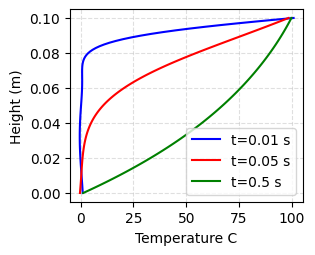

In [ ]:
fig, ax  = plt.subplots(1,1, figsize=(3,2.5))
ax.plot(T_plot1, y_plot1, color='blue', label="t=0.01 s")
ax.plot(T_plot2, y_plot2, color='red', label="t=0.05 s")
ax.plot(T_plot3, y_plot3, color='green', label="t=0.5 s")
ax.set_xlim([-5,105])
ax.set_ylim([-0.005, 0.105])
ax.legend()
ax.grid(ls='--', color="gray", alpha=0.25)
ax.set_xlabel("Temperature C")
ax.set_ylabel("Height (m)")
plt.show()
